# TP 4: Réseau de neurone MLP - classification avec Keras

**MLP = Multi-Layer Perceptron**

## Import des librairies

In [1]:
# Ignore warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=all, 1=info, 2=warning, 3=error only
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

## Chargement des données

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

## Séparation des données en jeux d'entraînement et de test

In [3]:
# Création du test set
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
# Création des train set & validation sets
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [4]:
X_test.shape

(10000, 28, 28)

Test set = 10,000 images

In [5]:
X_train.shape

(55000, 28, 28)

In [6]:
X_valid.shape

(5000, 28, 28)

### Normalisation de la valeur des pixels

Il est toujours préférable de normaliser les valeurs d'entrée d'un réseau de neurones. Ici on normalise la valeur des pixels entre O et 1 contre 0 à 255 initialement.

In [7]:
# Normalisation de la valeur des pixels entre 0 et 1 (vs 0-255)
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

## Visualisation d'une image

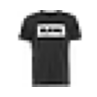

In [8]:
# Sélectionner une image
image_nb = 1
X_sample = X_train[image_nb].reshape(28, 28)
# Construction de l'image
plt.figure(figsize=(1,1))
plt.imshow(X_sample, cmap="binary")
plt.axis('off')
plt.show()

## Labellisation des images

Par défaut, les labels sont des chiffres, ce qui n'est pas très explicite. Il est préférable d'y affecter des noms de vêtement.

In [9]:
class_names = ["T-shirt/top", "Pantalon", "Pull", "Robe", "Manteau",
               "Sandales", "Chemisier", "Baskets", "Sac", "Boots"]
# Test immage
class_names[y_train[image_nb]]

'T-shirt/top'

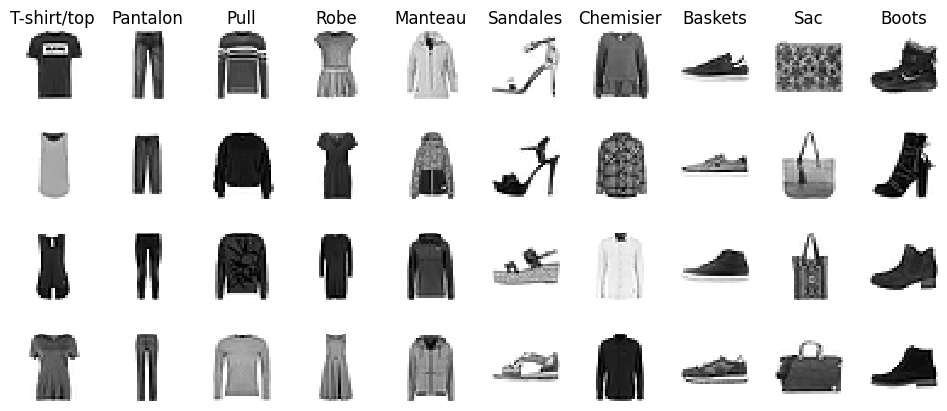

In [10]:
# extra code – this cell generates Figure 9–10
n_rows = 4
plt.figure(figsize=(12, n_rows * 1.2))
for row in range(n_rows):
    for class_index in range(10):
        X_img = X_train[y_train==class_index][row].reshape(28, 28)
        y_img = y_train[y_train==class_index][row]
        plt.subplot(n_rows, 10, 10 * row + class_index + 1)
        plt.imshow(X_img, cmap="binary", interpolation="nearest")
        plt.axis('off')
        if row == 0:
            plt.title(class_names[y_img])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

plt.show()

## Construction du réseau de neurone MLP pour tâche de classification

### Définition de l'architecture du modèle

In [11]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

In [12]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(input_shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

### Calcul du nombre de paramètres

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]

In [15]:
weights, biases = model.layers[1].get_weights()
weights

array([[ 0.01414002, -0.00919546, -0.05632558, ..., -0.04657503,
         0.01163516,  0.03361385],
       [ 0.01692729, -0.04815877,  0.02681534, ...,  0.04689629,
         0.01805417,  0.02158581],
       [ 0.04151126, -0.00324997,  0.03958718, ..., -0.03358795,
         0.01657537, -0.06764529],
       ...,
       [ 0.01812997, -0.05278846,  0.06286477, ..., -0.03665256,
         0.04327296, -0.0508161 ],
       [-0.06479496, -0.0443316 ,  0.02699487, ...,  0.01725664,
         0.05130608,  0.02114923],
       [ 0.03313534,  0.02258107,  0.03569658, ...,  0.06249489,
         0.051805  ,  0.05454333]], shape=(784, 300), dtype=float32)

In [16]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [17]:
# Dimension de la matrice des poids => 235,200 paramètres
weights.shape

(784, 300)

In [18]:
# Dimension du vecteur de biais => 300 paramètres
biases.shape

(300,)

### Compilation / préparation du modèle

In [19]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

### Entraînement

In [20]:
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7650 - loss: 0.7087 - val_accuracy: 0.8288 - val_loss: 0.5028
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8301 - loss: 0.4877 - val_accuracy: 0.8398 - val_loss: 0.4521
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8449 - loss: 0.4446 - val_accuracy: 0.8426 - val_loss: 0.4284
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8528 - loss: 0.4182 - val_accuracy: 0.8522 - val_loss: 0.4138
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8594 - loss: 0.3984 - val_accuracy: 0.8554 - val_loss: 0.4028
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8651 - loss: 0.3823 - val_accuracy: 0.8580 - val_loss: 0.3937
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8694 - loss: 0.3688 - val_accuracy: 0.8598 - val_loss: 0.3854
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8732 - loss: 0.3572 - 

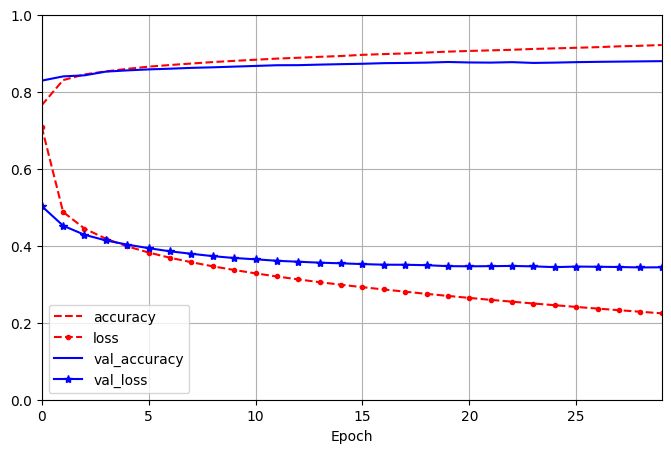

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code
plt.show()

In [26]:
mse_test, rmse_test = model.evaluate(X_test, y_test)
rmse_test

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step - accuracy: 0.8742 - loss: 0.3640


0.8741999864578247

### Prévisions avec le modèle

In [23]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.17, 0.  , 0.02, 0.  , 0.81],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [28]:
y_pred = y_proba.argmax(axis=-1)
y_pred

array([9, 2, 1])